DATA603: Principles of Machine Learning - Final Term Project

**A COMPREHENSIVE STUDY OF MACHINE LEARNING MODELS FOR CROSS-SITE SCRIPTING DETECTION**

*Name: Madhumitha Rajagopal*

*UID: 121331472*

### CNN Model

This is the code snippet for the CNN model on the XSS Dataset.

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import glob
import time
import pandas as pd
import os
import matplotlib.pyplot as plt
import keras
import cv2

In [25]:
# Load the dataset into a DataFrame
df=pd.read_csv('XSS_dataset.csv', encoding='utf-8-sig')

In [3]:
# first 5 rows of the DataFrame
df.head()

,Unnamed: 0,Sentence,Label
0,0,"<li><a href=""/wiki/File:Socrates.png"" class=""i...",0
1,1,"<tt onmouseover=""alert(1)"">test</tt>",1
2,2,"\t </span> <span class=""reference-text"">Steeri...",0
3,3,"\t </span> <span class=""reference-text""><cite ...",0
4,4,"\t </span>. <a href=""/wiki/Digital_object_iden...",0


In [4]:
# Keep only the last two columns of the DataFrame
df=df[df.columns[-2:]]

In [5]:
# Display the first 5 rows of the DataFrame
df.head()

,Sentence,Label
0,"<li><a href=""/wiki/File:Socrates.png"" class=""i...",0
1,"<tt onmouseover=""alert(1)"">test</tt>",1
2,"\t </span> <span class=""reference-text"">Steeri...",0
3,"\t </span> <span class=""reference-text""><cite ...",0
4,"\t </span>. <a href=""/wiki/Digital_object_iden...",0


In [6]:
# Extract the 'Sentence' column from the DataFrame
sentences=df['Sentence'].values
sentences[1]

'<tt onmouseover="alert(1)">test</tt>'

In [7]:
# Print the total number of sentences in the 'Sentence' column
print(len(sentences))

13686


In [8]:
# Function to convert a sentence to an ASCII representation with normalization
# This function replaces specific Unicode characters with designated ASCII values and normalizes the remaining characters that are within certain ranges.

def convert_to_ascii(sentence):
    sentence_ascii=[]

    for i in sentence:

        """Some characters have values very big e.d 8221 adn some are chinese letters
        I am removing letters having values greater than 8222 and for rest greater
        than 128 and smaller than 8222 assigning them values so they can easily be normalized"""

        if(ord(i)<8222):

            if(ord(i)==8217): # ’  :  8217
                sentence_ascii.append(134)


            if(ord(i)==8221): # ”  :  8221
                sentence_ascii.append(129)

            if(ord(i)==8220): # “  :  8220
                sentence_ascii.append(130)


            if(ord(i)==8216): # ‘  :  8216
                sentence_ascii.append(131)

            if(ord(i)==8217): # ’  :  8217
                sentence_ascii.append(132)

            if(ord(i)==8211): # –  :  8211
                sentence_ascii.append(133)


            """
            If values less than 128 store them else discard them
            """
            if (ord(i)<=128):
                    sentence_ascii.append(ord(i))

            else:
                    pass

    zer=np.zeros((10000))

    for i in range(len(sentence_ascii)):
        zer[i]=sentence_ascii[i]

    zer.shape=(100, 100)

    return zer

In [9]:
# Convert sentences into 3D array representations of images
# Each sentence is processed into a 100x100 ASCII matrix, resized, and normalized.

arr=np.zeros((len(sentences),100,100))

for i in range(len(sentences)):

    image=convert_to_ascii(sentences[i])

    x=np.asarray(image,dtype='float')
    image =  cv2.resize(x, dsize=(100,100), interpolation=cv2.INTER_CUBIC)
    image/=128

    arr[i]=image

In [10]:
print("Input data shape : ", arr.shape)

Input data shape :  (13686, 100, 100)


In [11]:
# Reshape the 3D array to include a channel dimension for compatibility with deep learning models
# The array is reshaped to have the shape (number of sentences, 100, 100, 1), where 1 represents the grayscale channel.

data = arr.reshape(arr.shape[0], 100, 100, 1)

In [12]:
data.shape

(13686, 100, 100, 1)

In [13]:
# Extract the 'Label' column from the DataFrame
y=df['Label'].values

In [14]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
trainX, testX, trainY, testY = train_test_split(data,y, test_size=0.2, random_state=42)

In [15]:
# Import necessary libraries
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Activation, Conv2D, MaxPooling2D,Flatten,Dropout,MaxPool2D, BatchNormalization

In [16]:
# A basic CNN Model
# Number of layers = 11
# Number of Convolutional layer: 3

model=tf.keras.models.Sequential([

    tf.keras.layers.Conv2D(64,(3,3), activation=tf.nn.relu, input_shape=(100,100,1)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128,(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(256,(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')

])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
# Compile the model with the binary cross-entropy loss function, the Adam optimizer, and accuracy as a metric
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# Print the model architecture summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 98, 98, 64)          │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 49, 49, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 47, 47, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 23, 23, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 21, 21, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 10, 10, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       6,553,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,964,737 (26.57 MB)

 Trainable params: 6,964,737 (26.57 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Stop when validation accuracy > 97

class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('val_accuracy')>0.97):
            print(" \n Reached 97% + validation accuracy")
            self.model.stop_training=True
callbacks = myCallback()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13686 entries, 0 to 13685
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  13686 non-null  int64 
 1   Sentence    13686 non-null  object
 2   Label       13686 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 320.9+ KB
None

First Few Rows of the Dataset:
   Unnamed: 0                                           Sentence  Label
0           0  <li><a href="/wiki/File:Socrates.png" class="i...      0
1           1               <tt onmouseover="alert(1)">test</tt>      1
2           2  \t </span> <span class="reference-text">Steeri...      0
3           3  \t </span> <span class="reference-text"><cite ...      0
4           4  \t </span>. <a href="/wiki/Digital_object_iden...      0

Missing Values:
Unnamed: 0    0
Sentence      0
Label         0
dtype: int64

Summary Statistics for Numerical Features:
         Unnamed: 0         

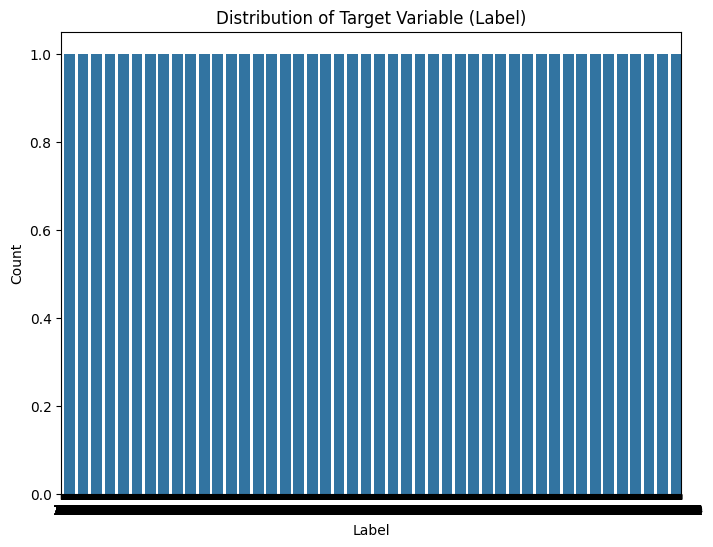

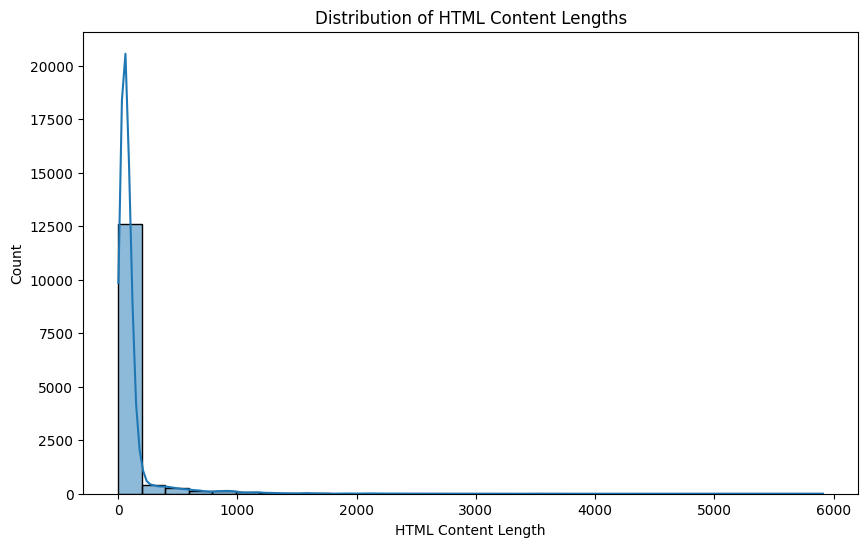

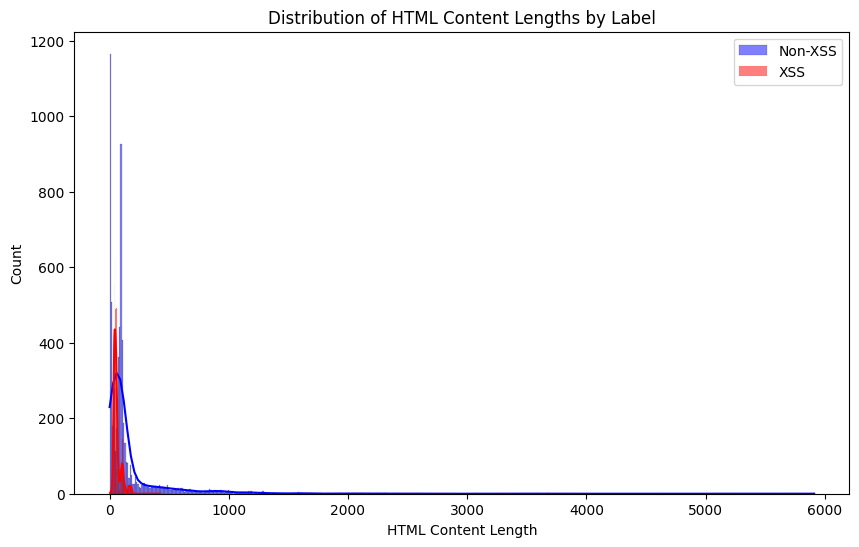

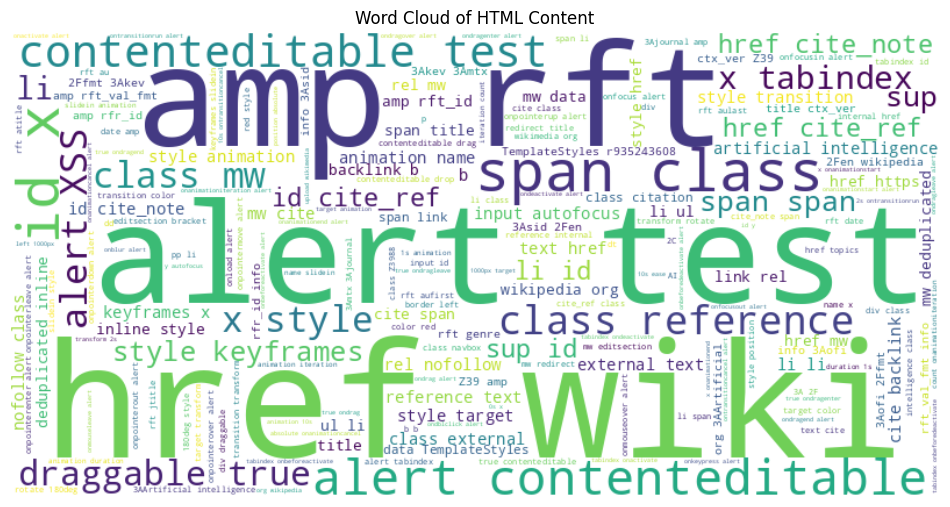

In [19]:
!pip install pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Dataset Information:")
print(data.info())

print("\nFirst Few Rows of the Dataset:")
print(data.head())

# Identify missing values in the dataset
missing_values = data.isnull().sum()
print("\nMissing Values:")
print(missing_values)

# Display summary statistics for numerical features
print("\nSummary Statistics for Numerical Features:")
print(data.describe())

# Plot the distribution of the target variable (Label)
plt.figure(figsize=(8, 6))
sns.countplot(data['Label'])
plt.title('Distribution of Target Variable (Label)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

# Create a new column for the length of the sentences
data['Sentence_length'] = data['Sentence'].apply(len)
# Plot the distribution of sentence lengths
plt.figure(figsize=(10, 6))
sns.histplot(data['Sentence_length'], bins=30, kde=True)
plt.title('Distribution of HTML Content Lengths')
plt.xlabel('HTML Content Length')
plt.ylabel('Count')
plt.show()

# Plot the distribution of sentence lengths by label
plt.figure(figsize=(10, 6))
sns.histplot(data[data['Label'] == 0]['Sentence_length'], color='blue', label='Non-XSS', kde=True)
sns.histplot(data[data['Label'] == 1]['Sentence_length'], color='red', label='XSS', kde=True)
plt.title('Distribution of HTML Content Lengths by Label')
plt.xlabel('HTML Content Length')
plt.ylabel('Count')
plt.legend()
plt.show()


from wordcloud import WordCloud

# Generate and display a word cloud of the sentences
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(data['Sentence']))
plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Word Cloud of HTML Content')
plt.axis('off')
plt.show()

In [20]:
# Train the model using the training data and validate it on the test data
batch_size = 128
num_epoch = 10

# Train the model with the specified parameters
model_log = model.fit(trainX, trainY,
          batch_size=batch_size,
          epochs=num_epoch,
          verbose=1,
          validation_data=( testX,  testY)
#                        callbacks=[callbacks]
                     )

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 34s 188ms/step - accuracy: 0.7520 - loss: 0.5009 - val_accuracy: 0.8112 - val_loss: 0.3964
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - accuracy: 0.8802 - loss: 0.2791 - val_accuracy: 0.9697 - val_loss: 0.0861
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - accuracy: 0.9808 - loss: 0.0665 - val_accuracy: 0.9817 - val_loss: 0.0612
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - accuracy: 0.9857 - loss: 0.0521 - val_accuracy: 0.9861 - val_loss: 0.0561
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - accuracy: 0.9864 - loss: 0.0501 - val_accuracy: 0.9861 - val_loss: 0.0500
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - accuracy: 0.9884 - loss: 0.0429 - val_accuracy: 0.9825 - val_loss: 0.0745
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - accuracy: 0.9891 - loss: 0.0400 - val_accuracy: 0.9865 - val_loss: 0.0458
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - accuracy: 0.9896 - loss: 0.0355 - val_accuracy: 0.9872

86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step


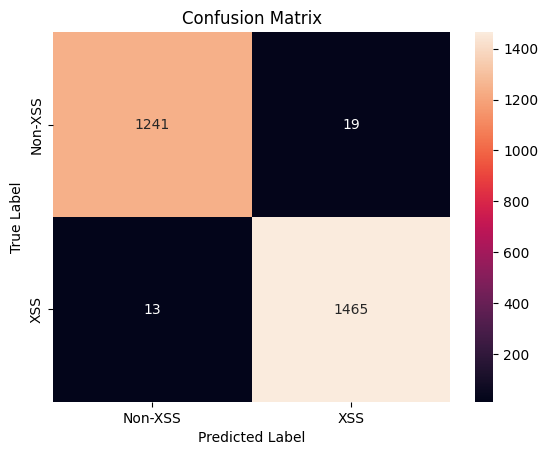

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Evaluate the model's performance on the test set using a confusion matrix

# Predict the labels for the test set
y_pred = model.predict(testX)

# Convert the predicted probabilities to binary labels (0 or 1)
y_pred_binary = [int(round(p[0])) for p in y_pred]

# Compute the confusion matrix for the true and predicted labels
cm = confusion_matrix(testY, y_pred_binary)

# Define labels for the confusion matrix
labels = ['Non-XSS', 'XSS']

# Visualize the confusion matrix using a heatmap
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [24]:
from sklearn.metrics import precision_score, recall_score

y_pred = model.predict(testX)
y_pred_binary = [int(round(p[0])) for p in y_pred]

# Calculate precision and recall
precision = precision_score(testY, y_pred_binary)
recall = recall_score(testY, y_pred_binary)

# Create a summary table containing accuracy, validation accuracy, loss, validation loss, precision, and recall.
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Validation Accuracy', 'Loss', 'Validation Loss', 'Precision', 'Recall'],
    'Value': [
        model_log.history['accuracy'][-1],
        model_log.history['val_accuracy'][-1],
        model_log.history['loss'][-1],
        model_log.history['val_loss'][-1],
        precision,
        recall
    ]
})

print(metrics_df.to_string())

86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
                Metric     Value
0             Accuracy  0.992145
1  Validation Accuracy  0.988313
2                 Loss  0.025594
3      Validation Loss  0.036848
4            Precision  0.987197
5               Recall  0.991204
